# 05 — Evaluation (Reproduce Table 1)

Evaluates trained models on the held-out test set.

Target metrics (paper Table 1, 1:5 ratio rows):

| Model  | BACC | AUC  | F1   | MCC  | Precision | Se   | Sp   |
|--------|------|------|------|------|-----------|------|------|
| 3T3    | 0.92 | 0.92 | 0.90 | 0.88 | 0.96      | 0.84 | 0.99 |
| HEK293 | 0.90 | 0.90 | 0.87 | 0.84 | 0.92      | 0.82 | 0.99 |

In [5]:
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, f1_score,
    matthews_corrcoef, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/results', exist_ok=True)

In [6]:
def evaluate_model(clf, X_test, y_test):
    """Compute all metrics from paper Table 1."""
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    Se   = tp / (tp + fn)  # sensitivity / recall
    Sp   = tn / (tn + fp)  # specificity
    Prec = tp / (tp + fp)
    BACC = (Se + Sp) / 2
    MCC  = (tp*tn - fp*fn) / math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    F1   = 2 * (Prec * Se) / (Prec + Se)
    AUC  = roc_auc_score(y_test, y_prob)

    return {
        'BACC': round(BACC, 2), 'AUC': round(AUC, 2), 'F1': round(F1, 2),
        'MCC':  round(MCC, 2),  'Precision': round(Prec, 2),
        'Se':   round(Se, 2),   'Sp': round(Sp, 2)
    }, cm


=== 3T3 ===
  X_test: (4809, 1024)  cytotoxic=801  non-toxic=4,008
  Metrics: {'BACC': 0.92, 'AUC': 0.98, 'F1': 0.9, 'MCC': 0.88, 'Precision': 0.94, 'Se': 0.86, 'Sp': 0.99}


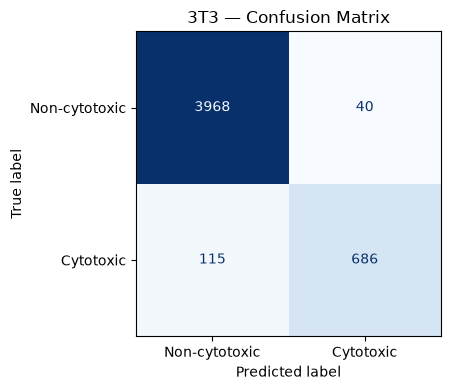

  Confusion matrix saved.

=== HEK293 ===
  X_test: (7370, 1024)  cytotoxic=1,228  non-toxic=6,142
  Metrics: {'BACC': 0.9, 'AUC': 0.97, 'F1': 0.86, 'MCC': 0.84, 'Precision': 0.92, 'Se': 0.81, 'Sp': 0.99}


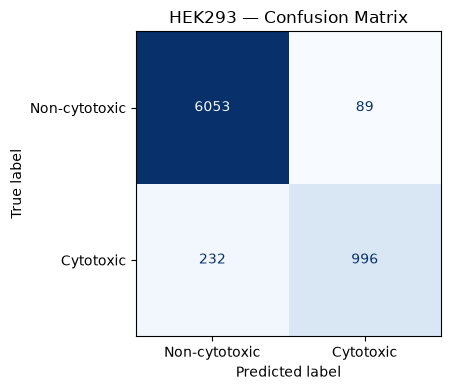

  Confusion matrix saved.


In [7]:
DATASETS = ['3T3', 'HEK293']
all_metrics = {}

for name in DATASETS:
    print(f'\n=== {name} ===')

    # Load model
    model_path = f'../model/{name}_lgbm_ecfp4.joblib'
    if not os.path.exists(model_path):
        print(f'  Model not found at {model_path} — run 04_train_lgbm.py first.')
        continue
    clf = load(model_path)

    # Load test fingerprints
    with open(f'../data/fp/{name}_ecfp4_test.json') as f:
        X_test = np.asarray(json.load(f))
    with open(f'../data/fp/{name}_y_test.json') as f:
        y_test = np.asarray(json.load(f), dtype=int)

    print(f'  X_test: {X_test.shape}  cytotoxic={y_test.sum():,}  non-toxic={(y_test==0).sum():,}')

    metrics, cm = evaluate_model(clf, X_test, y_test)
    all_metrics[name] = metrics

    print(f'  Metrics: {metrics}')

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-cytotoxic', 'Cytotoxic'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'../data/results/{name}_confusion_matrix.png', dpi=150)
    plt.show()
    print(f'  Confusion matrix saved.')

In [8]:
# Comparison table vs paper
paper_values = {
    '3T3':    {'BACC': 0.92, 'AUC': 0.92, 'F1': 0.90, 'MCC': 0.88, 'Precision': 0.96, 'Se': 0.84, 'Sp': 0.99},
    'HEK293': {'BACC': 0.90, 'AUC': 0.90, 'F1': 0.87, 'MCC': 0.84, 'Precision': 0.92, 'Se': 0.82, 'Sp': 0.99},
}

rows = []
for name in DATASETS:
    if name not in all_metrics:
        continue
    for metric in ['BACC', 'AUC', 'F1', 'MCC', 'Precision', 'Se', 'Sp']:
        rows.append({
            'Cell line': name,
            'Metric': metric,
            'Reproduced': all_metrics[name][metric],
            'Paper': paper_values[name][metric],
            'Diff': round(all_metrics[name][metric] - paper_values[name][metric], 3),
        })

comparison_df = pd.DataFrame(rows)
print('\nComparison with paper Table 1:')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('../data/results/table1_comparison.csv', index=False)


Comparison with paper Table 1:
Cell line    Metric  Reproduced  Paper  Diff
      3T3      BACC        0.92   0.92  0.00
      3T3       AUC        0.98   0.92  0.06
      3T3        F1        0.90   0.90  0.00
      3T3       MCC        0.88   0.88  0.00
      3T3 Precision        0.94   0.96 -0.02
      3T3        Se        0.86   0.84  0.02
      3T3        Sp        0.99   0.99  0.00
   HEK293      BACC        0.90   0.90  0.00
   HEK293       AUC        0.97   0.90  0.07
   HEK293        F1        0.86   0.87 -0.01
   HEK293       MCC        0.84   0.84  0.00
   HEK293 Precision        0.92   0.92  0.00
   HEK293        Se        0.81   0.82 -0.01
   HEK293        Sp        0.99   0.99  0.00
